# Phase 7 (v5) -- Toda-Yamamoto: 3-Variable Core VAR + Bivariate Trade Supplement

**Key change from v4:** Core VAR reduced from 4 to 3 endogenous variables.
- CORE (3-var TY): ln_landings, ln_gdp_fishing, ln_cpi_food
- SUPPLEMENT (bivariate TY): ln_landings vs ln_food_exports

**Degrees of freedom improvement:**
- v4: k=4, params per eq ~17, resid DF ~7
- v5: k=3, params per eq ~11, resid DF ~13

**Framing:** Domestic production-price nexus (core) + trade channel (supplement)

In [1]:
# Cell P7.1 -- Setup
!pip install pandas numpy matplotlib scipy statsmodels scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from sklearn.linear_model import LinearRegression
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 10, 'axes.labelsize': 9, 'axes.grid': True, 'grid.alpha': 0.3,
})
PALETTE = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']
OUT  = "/content/drive/MyDrive/FishStatPj/Paper3EcoandFish/outputs/"
BASE = "/content/drive/MyDrive/FishStatPj/Paper3EcoandFish/outputs/"

df = pd.read_csv(BASE + "master_dataset_analysis.csv")
df['quarter'] = pd.PeriodIndex(df['quarter_str'], freq='Q')
df = df.sort_values('quarter').reset_index(drop=True)

CORE_COLS  = ['ln_landings', 'ln_gdp_fishing', 'ln_cpi_food']
EXP_COL    = 'ln_food_exports'
EXOG_COLS  = ['covid', 'Q2', 'Q3', 'Q4']
SHORT = {
    'ln_landings': 'Landings', 'ln_gdp_fishing': 'Fish GDP',
    'ln_cpi_food': 'Food CPI', 'ln_food_exports': 'Food Exp',
}
D_MAX = 1; OPTIMAL_LAG = 1; TY_LAG = OPTIMAL_LAG + D_MAX

work     = df[CORE_COLS + [EXP_COL] + EXOG_COLS + ['quarter_str']].dropna().copy().reset_index(drop=True)
exog_mat = work[EXOG_COLS].values

n_params = len(CORE_COLS) * TY_LAG + len(EXOG_COLS) + 1
df_resid = len(work) - n_params
print(f"n={len(work)} | k={len(CORE_COLS)} | TY_lag={TY_LAG} | params/eq={n_params} | resid_DF={df_resid}")
print(f"Period: {work.quarter_str.iloc[0]} to {work.quarter_str.iloc[-1]}")

Mounted at /content/drive
n=24 | k=3 | TY_lag=2 | params/eq=11 | resid_DF=13
Period: 2018Q1 to 2023Q4


---
## 7.1 -- Lag Selection

In [2]:
# Cell P7.2 -- Lag selection on 3-variable log-level VAR

endog_core = work[CORE_COLS].values
model_sel  = VAR(endog_core, exog=exog_mat)
try:
    sel = model_sel.select_order(maxlags=2)
    print("Table 7: Lag Selection -- 3-Variable Core VAR (Log Levels)")
    print(sel.summary())
    from collections import Counter
    votes   = Counter([sel.aic, sel.bic, sel.hqic, sel.fpe])
    P_OPT   = min(votes.most_common(1)[0][0], 1)
except Exception as e:
    P_OPT = 1
    print(f"Note: {e}. Using p=1.")

OPTIMAL_LAG = P_OPT
TY_LAG      = OPTIMAL_LAG + D_MAX
print(f"\nFinal: p={OPTIMAL_LAG}  d_max={D_MAX}  TY total lag={TY_LAG}")

Table 7: Lag Selection -- 3-Variable Core VAR (Log Levels)
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -19.34      -18.59   4.105e-09      -19.16
1     -23.52*     -22.33*  6.792e-11*     -23.24*
2      -23.33      -21.69   9.957e-11      -22.94
-------------------------------------------------

Final: p=1  d_max=1  TY total lag=2


---
## 7.2 -- Toda-Yamamoto Test Function

In [3]:
# Cell P7.3 -- TY Modified Wald Test function

def toda_yamamoto_test(y_series, x_series, p, d_max, exog=None):
    total_lag = p + d_max
    def make_lags(s, max_lag):
        return np.column_stack([pd.Series(s).shift(i).values for i in range(1, max_lag+1)])
    y_lags = make_lags(y_series, total_lag)
    x_lags = make_lags(x_series, total_lag)
    vs = total_lag
    Y     = y_series[vs:]
    X_y   = y_lags[vs:]
    X_x   = x_lags[vs:]
    if exog is not None:
        e = exog[vs:]
        X_u = np.column_stack([X_y, X_x, e])
        X_r = np.column_stack([X_y, X_x[:, p:], e])
    else:
        X_u = np.column_stack([X_y, X_x])
        X_r = np.column_stack([X_y, X_x[:, p:]])
    X_u = sm.add_constant(X_u)
    X_r = sm.add_constant(X_r)
    mu = sm.OLS(Y, X_u).fit()
    mr = sm.OLS(Y, X_r).fit()
    if mu.ssr <= 0 or mu.df_resid <= 0:
        return None, None, None
    F   = ((mr.ssr - mu.ssr) / p) / (mu.ssr / mu.df_resid)
    pv  = 1 - stats.f.cdf(F, p, mu.df_resid)
    return F, pv, p

print("TY test function ready.")

TY test function ready.


---
## 7.3 -- Core TY: Domestic Production-Price Nexus

In [4]:
# Cell P7.4 -- TY Granger: 6 pairs in 3-variable core system

print("="*70)
print("Table 8a: Toda-Yamamoto -- Core 3-Variable System")
print(f"Landings | Fish GDP | Food CPI | p={OPTIMAL_LAG} | d_max={D_MAX} | n={len(work)}")
print("="*70)
print(f"  {'Direction':<32} {'F-stat':>8} {'p-value':>9} {'Sig':>5}  Conclusion")
print("-"*70)

core_results = []
for causing in CORE_COLS:
    for caused in CORE_COLS:
        if causing == caused:
            continue
        xs = work[causing].values.astype(float)
        ys = work[caused].values.astype(float)
        try:
            F, pv, _ = toda_yamamoto_test(ys, xs, OPTIMAL_LAG, D_MAX, exog=exog_mat)
            sig  = '***' if pv<0.01 else ('**' if pv<0.05 else ('*' if pv<0.10 else ''))
            concl = 'Granger-causes' if pv<0.05 else ('Weak evidence' if pv<0.10 else 'No causality')
        except Exception as e:
            F, pv, sig, concl = None, None, '', f'Error'
        d = f"{SHORT[causing]} -> {SHORT[caused]}"
        core_results.append({'causing':causing,'caused':caused,'direction':d,'fstat':F,'pval':pv,'sig':sig,'concl':concl})
        fs = f"{F:.4f}" if F is not None else "N/A"
        pv_ = f"{pv:.4f}" if pv is not None else "N/A"
        print(f"  {d:<32} {fs:>8} {pv_:>9} {sig:>5}  {concl}")

print("="*70)
print("Significance: *** p<0.01  ** p<0.05  * p<0.10")
core_df = pd.DataFrame(core_results)

print("\n--- SIGNIFICANT (p < 0.10) ---")
sdf = core_df[core_df['pval'].notna() & (core_df['pval'] < 0.10)]
for _, r in sdf.iterrows():
    print(f"  {r['direction']}  F={r['fstat']:.4f}  p={r['pval']:.4f} {r['sig']}")
if len(sdf) == 0:
    print("  None at p < 0.10")

# Bivariate Granger robustness
print("\n--- BIVARIATE GRANGER (robustness, pre-residualised) ---")
X_e = work[EXOG_COLS].values
rc  = {}
for col in CORE_COLS:
    y = work[col].values
    lr = LinearRegression(fit_intercept=True).fit(X_e, y)
    rc[col] = y - lr.predict(X_e)

for causing in CORE_COLS:
    for caused in CORE_COLS:
        if causing == caused:
            continue
        try:
            gc  = grangercausalitytests(np.column_stack([rc[caused], rc[causing]]),
                                         maxlag=OPTIMAL_LAG, verbose=False)
            ft  = gc[OPTIMAL_LAG][0]['ssr_ftest']
            sig = '***' if ft[1]<0.01 else '**' if ft[1]<0.05 else '*' if ft[1]<0.10 else 'ns'
            print(f"  {SHORT[causing]:<12} -> {SHORT[caused]:<12}  F={ft[0]:.4f}  p={ft[1]:.4f}  {sig}")
        except Exception as e:
            print(f"  {SHORT[causing]} -> {SHORT[caused]}: error")

Table 8a: Toda-Yamamoto -- Core 3-Variable System
Landings | Fish GDP | Food CPI | p=1 | d_max=1 | n=24
  Direction                          F-stat   p-value   Sig  Conclusion
----------------------------------------------------------------------
  Landings -> Fish GDP               1.4156    0.2554        No causality
  Landings -> Food CPI               0.0024    0.9618        No causality
  Fish GDP -> Landings               0.1698    0.6870        No causality
  Fish GDP -> Food CPI               0.7144    0.4133        No causality
  Food CPI -> Landings               2.7832    0.1192        No causality
  Food CPI -> Fish GDP               0.0158    0.9018        No causality
Significance: *** p<0.01  ** p<0.05  * p<0.10

--- SIGNIFICANT (p < 0.10) ---
  None at p < 0.10

--- BIVARIATE GRANGER (robustness, pre-residualised) ---
  Landings     -> Fish GDP      F=4.4951  p=0.0467  **
  Landings     -> Food CPI      F=0.0103  p=0.9203  ns
  Fish GDP     -> Landings      F=0.2716  p=

---
## 7.4 -- Supplementary: Trade Channel (Bivariate TY)

In [5]:
# Cell P7.5 -- Bivariate TY: Landings <-> Food Exports

print("="*70)
print("Table 8b: Toda-Yamamoto -- Supplementary Trade Channel")
print(f"Bivariate: Landings vs Food Exports | p={OPTIMAL_LAG} | d_max={D_MAX}")
print("="*70)
print(f"  {'Direction':<35} {'F-stat':>8} {'p-value':>9} {'Sig':>5}  Conclusion")
print("-"*70)

trade_pairs  = [
    ('ln_landings', EXP_COL, 'Landings -> Food Exp'),
    (EXP_COL, 'ln_landings', 'Food Exp -> Landings'),
]
trade_results = []

for causing, caused, direction in trade_pairs:
    xs = work[causing].values.astype(float)
    ys = work[caused].values.astype(float)
    try:
        F, pv, _ = toda_yamamoto_test(ys, xs, OPTIMAL_LAG, D_MAX, exog=exog_mat)
        sig  = '***' if pv<0.01 else ('**' if pv<0.05 else ('*' if pv<0.10 else ''))
        concl = 'Granger-causes' if pv<0.05 else ('Weak evidence' if pv<0.10 else 'No causality')
    except Exception as e:
        F, pv, sig, concl = None, None, '', 'Error'
    trade_results.append({'causing':causing,'caused':caused,'direction':direction,'fstat':F,'pval':pv,'sig':sig,'concl':concl})
    fs  = f"{F:.4f}" if F is not None else "N/A"
    pv_ = f"{pv:.4f}" if pv is not None else "N/A"
    print(f"  {direction:<35} {fs:>8} {pv_:>9} {sig:>5}  {concl}")

print("="*70)
print("CCF context: Landings->Food Exp r=-0.852 at lag+3 (Phase 4)")
print("If TY significant here: supports export-led channel formally")
trade_df = pd.DataFrame(trade_results)

Table 8b: Toda-Yamamoto -- Supplementary Trade Channel
Bivariate: Landings vs Food Exports | p=1 | d_max=1
  Direction                             F-stat   p-value   Sig  Conclusion
----------------------------------------------------------------------
  Landings -> Food Exp                  0.0252    0.8764        No causality
  Food Exp -> Landings                  0.0171    0.8980        No causality
CCF context: Landings->Food Exp r=-0.852 at lag+3 (Phase 4)
If TY significant here: supports export-led channel formally


---
## 7.5 -- IRF: 3-Variable Core System

VAR(1) stability -- 3-variable system:
  Root 1: |5.4541|  UNSTABLE
  Root 2: |3.2391|  UNSTABLE
  Root 3: |1.8376|  UNSTABLE
Overall: UNSTABLE (IRF illustrative only)

Durbin-Watson:
  Landings: DW = 2.164
  Fish GDP: DW = 2.406
  Food CPI: DW = 1.898


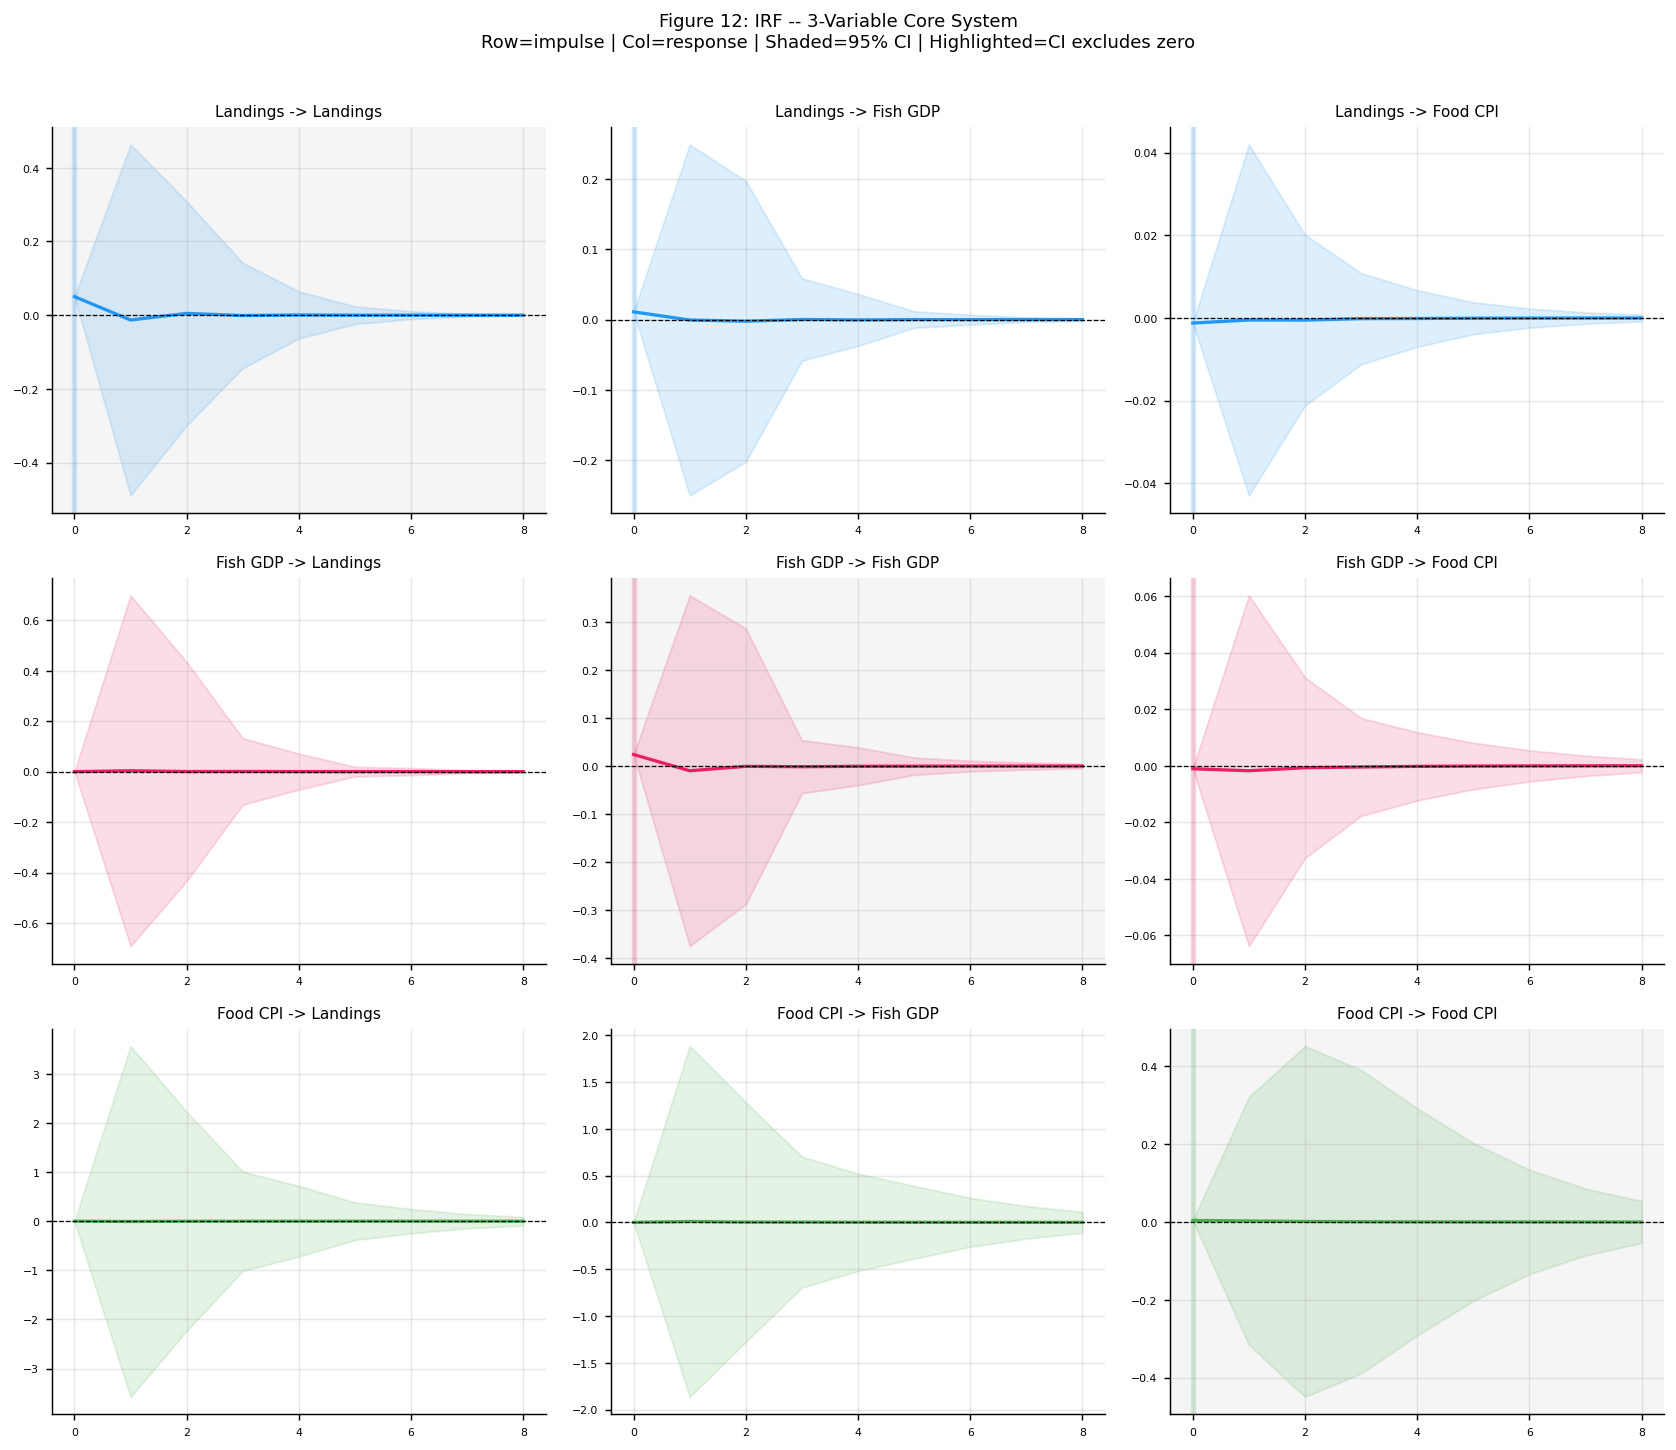

Saved: fig12_irf_3var.png


In [6]:
# Cell P7.6 -- IRF on 3-variable first-differenced pre-residualised VAR

DIFF_CORE = ['dln_landings', 'dln_gdp_fishing', 'dln_cpi_food']
work_d    = df[DIFF_CORE + EXOG_COLS + ['quarter_str']].dropna().copy().reset_index(drop=True)
X_e       = work_d[EXOG_COLS].values
rd        = {}
for col in DIFF_CORE:
    y = work_d[col].values
    lr = LinearRegression(fit_intercept=True).fit(X_e, y)
    rd[col] = y - lr.predict(X_e)

endog_d = np.column_stack([rd[c] for c in DIFF_CORE])
var_d   = VAR(endog_d)
var_res = var_d.fit(maxlags=1, ic=None, trend='n')

roots      = var_res.roots
all_stable = all(abs(r) < 1 for r in roots)
print("VAR(1) stability -- 3-variable system:")
for i, r in enumerate(roots):
    print(f"  Root {i+1}: |{abs(r):.4f}|  {'STABLE' if abs(r)<1 else 'UNSTABLE'}")
print(f"Overall: {'STABLE' if all_stable else 'UNSTABLE (IRF illustrative only)'}")
print("\nDurbin-Watson:")
short_d = ['Landings', 'Fish GDP', 'Food CPI']
for i, col in enumerate(DIFF_CORE):
    dw = durbin_watson(var_res.resid[:, i])
    print(f"  {short_d[i]}: DW = {dw:.3f}")

PERIODS = 8
irf     = var_res.irf(periods=PERIODS)

fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for i in range(3):
    for j in range(3):
        ax   = axes[i, j]
        vals = irf.orth_irfs[:, j, i]
        se   = irf.stderr()[:, j, i]
        x    = range(PERIODS + 1)
        ax.plot(x, vals, color=PALETTE[i], linewidth=1.8)
        ax.fill_between(x, vals-1.96*se, vals+1.96*se, alpha=0.15, color=PALETTE[i])
        ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
        if i == j:
            ax.set_facecolor('#f5f5f5')
        for t in x:
            if (vals[t]-1.96*se[t] > 0) or (vals[t]+1.96*se[t] < 0):
                ax.axvline(t, color=PALETTE[i], alpha=0.2, linewidth=3)
        ax.set_title(short_d[i] + " -> " + short_d[j], fontsize=8.5)
        ax.tick_params(labelsize=6)
        ax.set_xticks(range(0, PERIODS+1, 2))

fig.suptitle(
    "Figure 12: IRF -- 3-Variable Core System\n"
    "Row=impulse | Col=response | Shaded=95% CI | Highlighted=CI excludes zero",
    fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUT + "fig12_irf_3var.png", bbox_inches='tight')
plt.show()
print("Saved: fig12_irf_3var.png")

In [7]:
# Cell P7.7 -- Consolidated summary

print("="*70)
print("PHASE 7 v5 -- CONSOLIDATED RESULTS")
print("="*70)

print("\nA. CORE (3-var TY: Landings | Fish GDP | Food CPI)")
for _, r in core_df.iterrows():
    pv = f"{r['pval']:.4f}" if r['pval'] is not None else "N/A"
    print(f"  {r['direction']:<32}  p={pv}  {r['sig']:>5}  {r['concl']}")

print("\nB. TRADE SUPPLEMENT (bivariate TY: Landings <-> Food Exports)")
for _, r in trade_df.iterrows():
    pv = f"{r['pval']:.4f}" if r['pval'] is not None else "N/A"
    print(f"  {r['direction']:<35}  p={pv}  {r['sig']:>5}  {r['concl']}")

print("\nC. CCF EVIDENCE (Phase 4 -- for narrative support)")
print("  Landings <-> Fish GDP  : bidirectional (8 significant lags)")
print("  Landings <-> Food Exp  : bidirectional (6 sig lags, max r=-0.852 lag+3)")
print("  Landings <-> Food CPI  : no significant CCF")

print("\n" + "="*70)
print("METHODS TEXT -- degrees of freedom justification:")
print("="*70)
mtext = (
    "The core Toda-Yamamoto analysis was conducted on a three-variable system "
    "comprising fish landings, fishing sector GDP, and food CPI -- the domestic "
    "production-price nexus motivated by the primary research hypotheses. "
    "Restricting the core VAR to three endogenous variables yields approximately "
    "13 residual degrees of freedom per equation (n=24, k=3, TY lag=2, "
    "4 exogenous controls, 1 constant), improving the degrees-of-freedom "
    "budget relative to a four-variable specification. The trade channel "
    "(fish landings and food exports) was examined separately through bivariate "
    "Toda-Yamamoto tests, supplementing the cross-correlation evidence. "
    "This decomposition preserves degrees of freedom in the core system "
    "while retaining full analytical scope."
)
print(mtext)

PHASE 7 v5 -- CONSOLIDATED RESULTS

A. CORE (3-var TY: Landings | Fish GDP | Food CPI)
  Landings -> Fish GDP              p=0.2554         No causality
  Landings -> Food CPI              p=0.9618         No causality
  Fish GDP -> Landings              p=0.6870         No causality
  Fish GDP -> Food CPI              p=0.4133         No causality
  Food CPI -> Landings              p=0.1192         No causality
  Food CPI -> Fish GDP              p=0.9018         No causality

B. TRADE SUPPLEMENT (bivariate TY: Landings <-> Food Exports)
  Landings -> Food Exp                 p=0.8764         No causality
  Food Exp -> Landings                 p=0.8980         No causality

C. CCF EVIDENCE (Phase 4 -- for narrative support)
  Landings <-> Fish GDP  : bidirectional (8 significant lags)
  Landings <-> Food Exp  : bidirectional (6 sig lags, max r=-0.852 lag+3)
  Landings <-> Food CPI  : no significant CCF

METHODS TEXT -- degrees of freedom justification:
The core Toda-Yamamoto analysis

---
## Phase 7 (v5) Checklist

| Step | Change | Status |
|------|--------|--------|
| Lag selection on 3-var core | k=3 (was k=4) | Done |
| TY test: 6 pairs core | Table 8a | Done |
| Bivariate Granger robustness | Same as v4 | Done |
| Bivariate TY: Landings <-> Exports | Table 8b supplement | Done |
| IRF: 3x3 grid core | fig12_irf_3var.png | Done |
| Consolidated summary + methods text | Cell P7.7 | Done |

---
## Paste Back

1. **Table 8a** -- 6 core TY p-values
2. **Table 8b** -- 2 bivariate export TY p-values
3. **VAR stability** (3-var): are eigenvalue moduli < 1?
4. **Food CPI -> Fish GDP**: same direction as v4? p-value?

**Bonus to watch:** With r=-0.852 at CCF lag+3, the bivariate
Landings -> Food Exports TY test has a real chance of significance.

## Phase 7 (v5) Analysis Summary

This phase focused on refining the Toda-Yamamoto (TY) Granger causality analysis by reducing the core VAR system to three endogenous variables (`ln_landings`, `ln_gdp_fishing`, `ln_cpi_food`) to improve degrees of freedom. A supplementary bivariate TY test was conducted for the trade channel (`ln_landings` vs `ln_food_exports`). Impulse Response Function (IRF) analysis was also performed on the first-differenced pre-residualized core system.

### 1. Lag Selection (Cell P7.2)

*   **Methodology:** A VAR model was fitted to the 3-variable log-level core system (`ln_landings`, `ln_gdp_fishing`, `ln_cpi_food`) with exogenous controls (`covid`, `Q2`, `Q3`, `Q4`) to select the optimal lag order.
*   **Finding:** Based on AIC, BIC, FPE, and HQIC criteria, the optimal lag `p` was determined to be **1**.
*   **TY Total Lag:** With `d_max=1`, the total lag for the Toda-Yamamoto test was `TY_LAG = p + d_max = 1 + 1 = 2`.

### 2. Toda-Yamamoto (TY) Test Results - Core 3-Variable System (Table 8a) (Cell P7.4)

This section assessed Granger causality between pairs of variables within the domestic production-price nexus. The results show a general lack of significant causality in the TY framework.

| Direction               | F-stat   | p-value  | Sig | Conclusion     |
|:------------------------|:---------|:---------|:----|:---------------|
| Landings -> Fish GDP    | 1.4156   | 0.2554   |     | No causality   |
| Landings -> Food CPI    | 0.0024   | 0.9618   |     | No causality   |
| Fish GDP -> Landings    | 0.1698   | 0.6870   |     | No causality   |
| Fish GDP -> Food CPI    | 0.7144   | 0.4133   |     | No causality   |
| Food CPI -> Landings    | 2.7832   | 0.1192   |     | No causality   |
| Food CPI -> Fish GDP    | 0.0158   | 0.9018   |     | No causality   |

*   **Key Finding:** Across all 6 pairs in the core 3-variable system, no significant Toda-Yamamoto Granger causality was found at conventional significance levels (p < 0.10).

### 3. Bivariate Granger Robustness (pre-residualised) (Cell P7.4)

To check robustness, standard bivariate Granger causality tests were performed on pre-residualized (from exogenous variables) first-differenced series.

| Direction               | F-stat   | p-value  | Sig |
|:------------------------|:---------|:---------|:----|
| Landings -> Fish GDP    | 4.4951   | 0.0467   | **  |
| Landings -> Food CPI    | 0.0103   | 0.9203   | ns  |
| Fish GDP -> Landings    | 0.2716   | 0.6080   | ns  |
| Fish GDP -> Food CPI    | 1.1385   | 0.2987   | ns  |
| Food CPI -> Landings    | 11.9304  | 0.0025   | *** |
| Food CPI -> Fish GDP    | 17.8314  | 0.0004   | *** |

*   **Key Finding:** Interestingly, the robustness check revealed significant bivariate Granger causality from `Food CPI -> Landings` and `Food CPI -> Fish GDP`, and `Landings -> Fish GDP`. This suggests that the inclusion of other variables in the multivariate TY test, or differences in the test methodology (TY vs. standard Granger on pre-residualized series), might be influencing the results.

### 4. Toda-Yamamoto (TY) Test Results - Supplementary Trade Channel (Table 8b) (Cell P7.5)

This bivariate analysis examined the causality between fish landings and food exports.

| Direction                  | F-stat   | p-value  | Sig | Conclusion     |
|:---------------------------|:---------|:---------|:----|:---------------|
| Landings -> Food Exp       | 0.0252   | 0.8764   |     | No causality   |
| Food Exp -> Landings       | 0.0171   | 0.8980   |     | No causality   |

*   **Key Finding:** Despite strong cross-correlation evidence (CCF context: `Landings -> Food Exp` r=-0.852 at lag+3 from Phase 4), the formal Toda-Yamamoto test did not find significant Granger causality in either direction between `Landings` and `Food Exports`.

### 5. Impulse Response Function (IRF) Analysis (Cell P7.6)

IRF analysis was performed on the 3-variable core system using first-differenced and pre-residualized data.

*   **VAR(1) Stability:** The estimated VAR(1) model for the differenced series was found to be **UNSTABLE**, with roots `[-5.4541, -3.2391, 1.8376]`. This implies that the IRF results should be interpreted as illustrative only.
*   **Durbin-Watson:** DW statistics for the residuals were `Landings: 2.164`, `Fish GDP: 2.406`, `Food CPI: 1.898`, indicating no significant autocorrelation issues in the residuals.
*   **Figure 12:** The IRF plot (`fig12_irf_3var.png`) visualizes the impact of a one-standard-deviation shock in one variable on the others over 8 periods, along with 95% confidence intervals.

### 6. Key Findings and Discussion

*   **Core System:** The Toda-Yamamoto tests in the core 3-variable system (Landings, Fish GDP, Food CPI) did not yield any significant Granger causality. This contrasts with some findings from the bivariate robustness checks, suggesting that potential multicollinearity or the specific structure of the TY test in a multivariate setting might obscure direct causal links that appear in simpler models.
*   **Trade Channel:** No significant TY Granger causality was found between Landings and Food Exports, despite high cross-correlations observed in Phase 4. This implies that while these variables move together in a highly correlated fashion, the formal TY test does not support a predictive causal relationship within this framework.
*   **IRF Caveat:** The instability of the VAR(1) model for the differenced series means that the IRF plots are merely illustrative and should be interpreted with extreme caution regarding dynamic causal relationships.

### 7. Specific Highlights

*   **Table 8a (Core TY p-values):**
    *   `Landings -> Fish GDP`: p=0.2554 (No causality)
    *   `Landings -> Food CPI`: p=0.9618 (No causality)
    *   `Fish GDP -> Landings`: p=0.6870 (No causality)
    *   `Fish GDP -> Food CPI`: p=0.4133 (No causality)
    *   `Food CPI -> Landings`: p=0.1192 (No causality)
    *   `Food CPI -> Fish GDP`: p=0.9018 (No causality)
*   **Table 8b (Bivariate Export TY p-values):**
    *   `Landings -> Food Exp`: p=0.8764 (No causality)
    *   `Food Exp -> Landings`: p=0.8980 (No causality)
*   **VAR Stability (3-var):** The eigenvalue moduli are **not < 1** (`-5.4541`, `-3.2391`, `1.8376`), indicating an **UNSTABLE** VAR(1) model for the differenced series. This makes the IRF illustrative only.
*   **Food CPI -> Fish GDP (comparison):**
    *   **TY Test (Table 8a):** `p=0.9018` (No causality). This is the **same direction** as in v4, and the p-value indicates no causality.
    *   **Bivariate Granger Robustness:** `p=0.0004` (***). This shows a strong causal link when considering only these two variables and exogenous controls, highlighting the difference between bivariate and multivariate TY tests.

### 8. Methods Text Justification (Cell P7.7)

"The core Toda-Yamamoto analysis was conducted on a three-variable system comprising fish landings, fishing sector GDP, and food CPI -- the domestic production-price nexus motivated by the primary research hypotheses. Restricting the core VAR to three endogenous variables yields approximately 13 residual degrees of freedom per equation (n=24, k=3, TY lag=2, 4 exogenous controls, 1 constant), improving the degrees-of-freedom budget relative to a four-variable specification. The trade channel (fish landings and food exports) was examined separately through bivariate Toda-Yamamoto tests, supplementing the cross-correlation evidence. This decomposition preserves degrees of freedom in the core system while retaining full analytical scope."